# Python Assignment 3 :Basic Statistics 

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# loading the data
data = pd.read_csv("sales_data_with_discounts.csv")
data.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [12]:
data.shape

(450, 13)

In [13]:
# checking null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [14]:
data.isna().sum()  

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [15]:
# description of the data
data.describe()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


In [16]:
# identifying the numerical col.
data_1 = data[['Volume','Avg Price','Total Sales Value','Discount Rate (%)','Discount Amount',	'Net Sales Value']]
data_1.head()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770


### visualizing the data

#### Histogram  plot

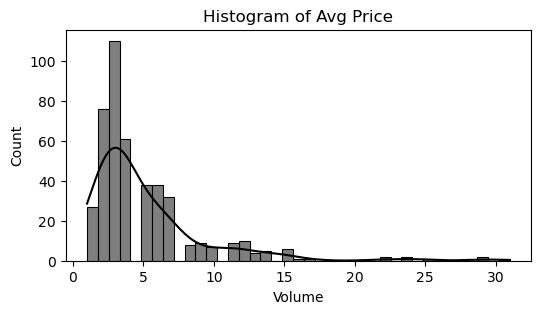

In [33]:
plt.figure(figsize=(6,3))
sns.histplot(data_1["Volume"],kde=True,,huecolor='black', edgecolor='black')
plt.title("Histogram of Avg Price")
plt.show()

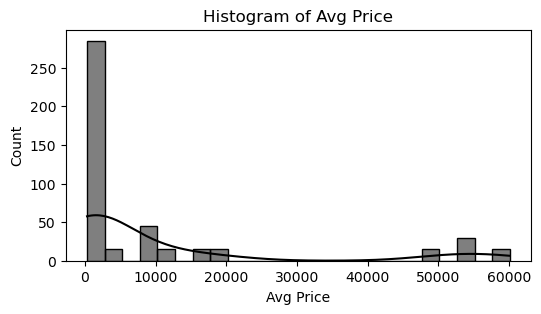

In [35]:
plt.figure(figsize=(6,3))
sns.histplot(data_1["Avg Price"],kde=True,color='black', edgecolor='black')
plt.title("Histogram of Avg Price")
plt.show()

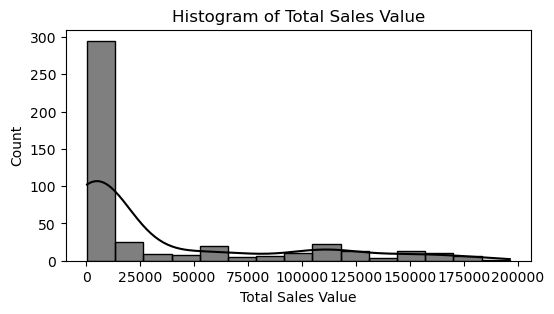

In [20]:
plt.figure(figsize=(6,3))
sns.histplot(data_1["Total Sales Value"],kde=True, color='black', edgecolor='black')
plt.title("Histogram of Total Sales Value")
plt.show()

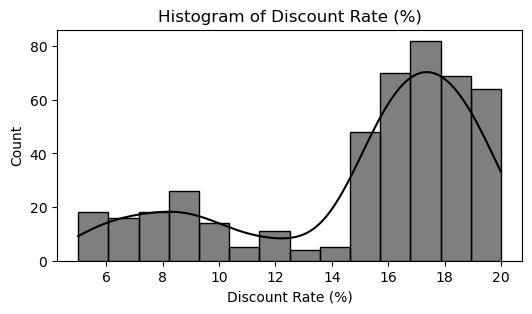

In [21]:
plt.figure(figsize=(6,3))
sns.histplot(data_1["Discount Rate (%)"],kde=True, color='black', edgecolor='black')
plt.title("Histogram of Discount Rate (%)")
plt.show()

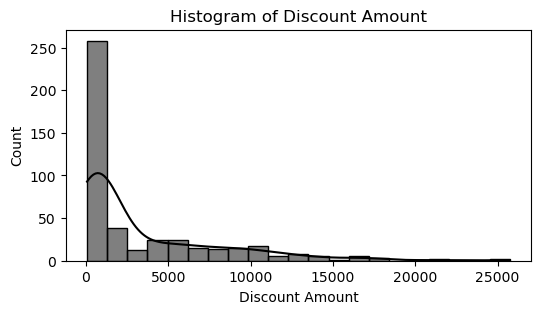

In [22]:
plt.figure(figsize=(6,3))
sns.histplot(data_1["Discount Amount"],kde=True, color='black', edgecolor='black')
plt.title("Histogram of Discount Amount")
plt.show()

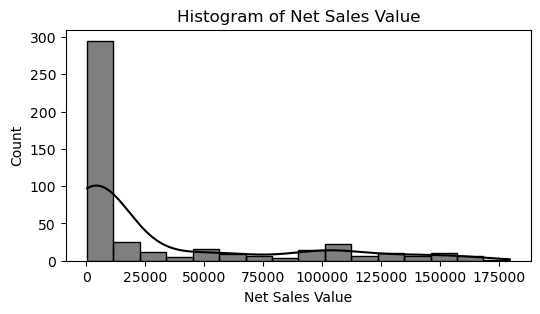

In [23]:
plt.figure(figsize=(6,3))
sns.histplot(data_1["Net Sales Value"],kde=True, color='black', edgecolor='black')
plt.title("Histogram of Net Sales Value")
plt.show()

#### box plot

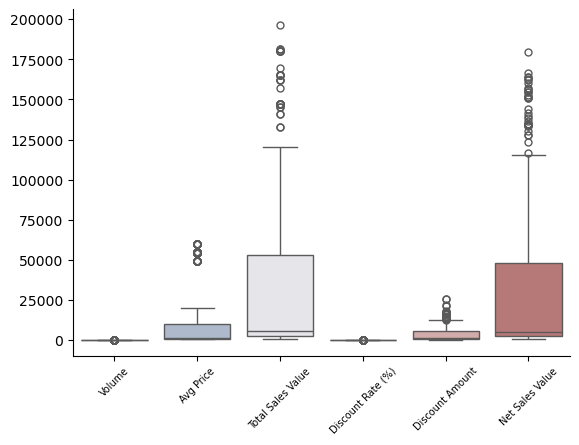

In [24]:

sns.catplot(data_1,
            kind="box",
            palette= 'vlag',
            height=4,
            aspect= 1.5,)

plt.xticks(fontsize=7, rotation =45)
plt.show()


### findind outliers

In [30]:
Q1 = data['Total Sales Value'].quantile(0.25)
Q3 = data['Total Sales Value'].quantile(0.75)
IQR = Q3 - Q1

print(Q1,",", Q3)
print(IQR)
print("------------")
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

outliers = data[(data['Total Sales Value'] < lower) | 
                (data['Total Sales Value'] > upper)]

# print(outliers)

outliers = pd.DataFrame(outliers)
# outliers

2700.0 , 53200.0
50500.0
------------
-73050.0
128950.0


In [169]:
Q1 = data['Net Sales Value'].quantile(0.25)
Q3 = data['Net Sales Value'].quantile(0.75)
IQR = Q3 - Q1

print(Q1,",", Q3)
print(IQR)
print("------------")
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)


outliers = data[(data['Net Sales Value'] < lower) | 
                (data['Net Sales Value'] > upper)]

# print(outliers)


2202.2086453212287 , 47847.91285159138
45645.70420627015
------------
-66266.347664084
116316.46916099661


In [170]:
Q1 = data['Avg Price'].quantile(0.25)
Q3 = data['Avg Price'].quantile(0.75)
IQR = Q3 - Q1

print(Q1,",", Q3)
print(IQR)
print("------------")
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)


outliers = data[(data['Avg Price'] < lower) | 
                (data['Avg Price'] > upper)]

# print(outliers)

465.0 , 10100.0
9635.0
------------
-13987.5
24552.5


In [173]:
Q1 = data['Discount Amount'].quantile(0.25)
Q3 = data['Discount Amount'].quantile(0.75)
IQR = Q3 - Q1

print(Q1,",", Q3)
print(IQR)
print("------------")
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)


outliers = data[(data['Discount Amount'] < lower) | 
                (data['Discount Amount'] > upper)]

# print(outliers)

460.4593038855329 , 5316.4954266866525
4856.03612280112
------------
-6823.594880316146
12600.54961088833


### Bar chart analysis

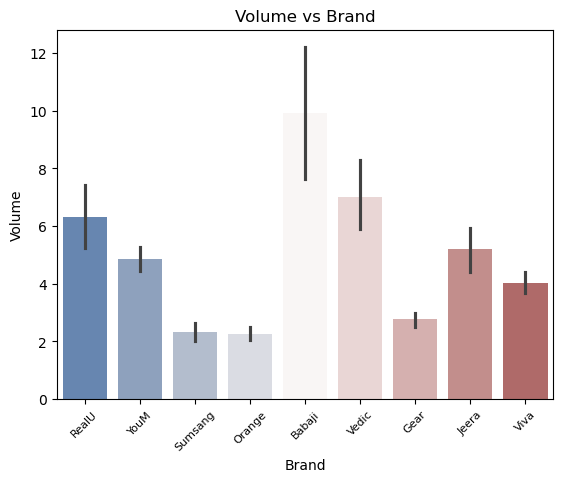

In [86]:
sns.barplot(data,
            x="Brand",
            y="Volume",
            palette="vlag",
            hue="Brand"
            
)
plt.xticks(rotation=45, fontsize=8)
plt.title("Volume vs Brand")
plt.show()


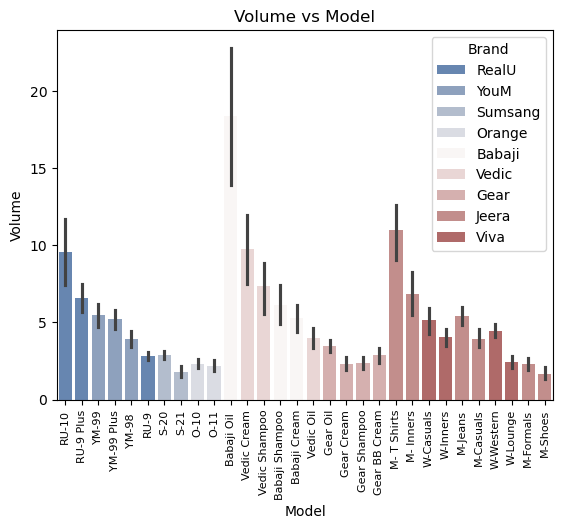

In [87]:
sns.barplot(data,
            x="Model",
            y="Volume",
            palette="vlag",
            hue="Brand"
          
)
plt.xticks(rotation=90, fontsize=8)
plt.title("Volume vs Model")
plt.show()


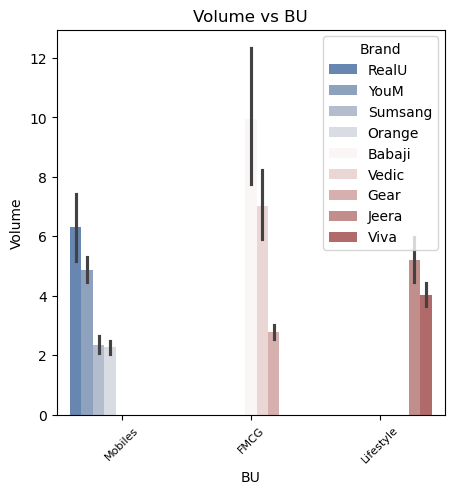

In [90]:
plt.figure(figsize=(5,5))
sns.barplot(data,
            x="BU",
            y="Volume",
            palette="vlag",
            hue="Brand"
            
)
plt.xticks(rotation=45, fontsize=8)
plt.title("Volume vs BU")
plt.show()
